# One flow for all disaster type groups

What if instead of having a model per disaster type we have a single one?  
Will the preformance worsen or will it learn some common patterns an improve as result?

#### imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from pathlib import Path
from scipy.stats import gaussian_kde
import time
import math

import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import zuko


In [2]:
DATASET_PATH = Path("../../datasets/disasters_merged_all_feats.csv")
RUN_PATH = Path(f"../../runs/flow_all.pt")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

np.random.seed(0)
torch.manual_seed(0)

## Data Preparation

In [3]:
df = pd.read_csv(DATASET_PATH)

### Group by event type

In [4]:
df['EVENT_GROUP'].value_counts()

EVENT_GROUP
Wind           152966
Hail            57980
Storm           55795
Flood           49691
Freeze          39347
Drought         20115
Snow            19792
Heat            14279
Heavy Rain      10488
Fog              4943
Wildfire         2505
Lightning        2261
Debris Flow      1047
Avalanche         203
Name: count, dtype: int64

In [5]:
event_group_dfs = {
    'Wind': df[df['EVENT_GROUP'] == 'Wind'],#.drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Storm': df[df['EVENT_GROUP'] == 'Storm'],#.drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Flood': df[df['EVENT_GROUP'] == 'Flood'],#.drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Freeze': df[df['EVENT_GROUP'] == 'Freeze'],#.drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Drought': df[df['EVENT_GROUP'] == 'Drought'],#.drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Snow': df[df['EVENT_GROUP'] == 'Snow'],#.drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Heat': df[df['EVENT_GROUP'] == 'Heat'],#.drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Heavy Rain': df[df['EVENT_GROUP'] == 'Heavy Rain'],#.drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Fog': df[df['EVENT_GROUP'] == 'Fog'],#.drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Wildfire': df[df['EVENT_GROUP'] == 'Wildfire'],#.drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Lightning': df[df['EVENT_GROUP'] == 'Lightning'],#.drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Debris Flow': df[df['EVENT_GROUP'] == 'Debris Flow'],#.drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Avalanche': df[df['EVENT_GROUP'] == 'Avalanche'],#.drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
}

### Sample dataset

In [6]:
N_POINTS = 200000

# build a single dataset sampling 100000 total points from the event groups, balancing the class distribution when possible
sampled_dfs = []
for group, df in event_group_dfs.items():
    n_samples = min(len(df), N_POINTS // len(event_group_dfs))
    sampled_df = df.sample(n=n_samples, random_state=42)
    sampled_dfs.append(sampled_df)

df = pd.concat(sampled_dfs, ignore_index=True)

In [7]:
df['EVENT_GROUP'].value_counts()

EVENT_GROUP
Wind           15384
Storm          15384
Flood          15384
Freeze         15384
Drought        15384
Snow           15384
Heat           14279
Heavy Rain     10488
Fog             4943
Wildfire        2505
Lightning       2261
Debris Flow     1047
Avalanche        203
Name: count, dtype: int64

### Data normalization

In [8]:
TARGET_COLS = ["DAMAGES", "CASUALTIES"]

X_COLS = [
    'BEGIN_LAT', 'BEGIN_LON',
    'DURATION_HOURS', 'WIND_SPEED', # change with hail size for hail
    'TIME_DAY_SIN', 'TIME_DAY_COS', 'TIME_YEAR_NORM',
    'PRECIPITATION', 'TMIN', 'TMAX',
    'ELEVATION', 'SLOPE',
    'COV_BARREN', 'COV_CULTIVATED', 'COV_VEGETATION',
    'COV_FOREST', 'COV_WATER', 'COV_SNOW_ICE', 'COV_URBAN',
    'RIVER_DISTANCE', 'SEA_DISTANCE',
]

In [9]:
X = df[X_COLS].values.astype(np.float32)
Y = df[TARGET_COLS].values.astype(np.float32)

In [10]:
# targets log transformation
Y = np.log1p(Y)

In [11]:
# train-val-test split
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)

X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

In [12]:
# standardize features and targets
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_val   = x_scaler.transform(X_val)
X_test  = x_scaler.transform(X_test)

Y_train = y_scaler.fit_transform(Y_train)
Y_val   = y_scaler.transform(Y_val)
Y_test  = y_scaler.transform(Y_test)


### Dataset split

In [13]:
# conversion to tensors and move to device
X_train = torch.tensor(X_train).to(device)
Y_train = torch.tensor(Y_train).to(device)

X_val = torch.tensor(X_val).to(device)
Y_val = torch.tensor(Y_val).to(device)

X_test = torch.tensor(X_test).to(device)
Y_test = torch.tensor(Y_test).to(device)


In [14]:
# data loaders
train_ds = TensorDataset(X_train, Y_train)
val_ds   = TensorDataset(X_val, Y_val)
test_ds   = TensorDataset(X_val, Y_val)

## Model

### Model definition

In [15]:
EPOCHS = 200
BATCH_SIZE = 512
BASE_LR = 5e-3

# find warmup steps as function of epochs and dataset size
WARMUP_STEPS = int(0.1 * (len(train_ds) // BATCH_SIZE) * EPOCHS)

In [16]:
flow = zuko.flows.NSF(
    features=2,
    context=21,
    transforms=8,
    hidden_features=[256, 256, 256],
    bins=16,
)


In [17]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader   = DataLoader(test_ds, batch_size=BATCH_SIZE)

In [18]:
flow = flow.to(device)
optimizer = torch.optim.Adam(flow.parameters(), lr=BASE_LR, weight_decay=1e-5)
total_steps = EPOCHS * len(train_loader)
warmup_steps = 5 * len(train_loader)

In [19]:
print(f"NSF model created with {sum(p.numel() for p in flow.parameters())} parameters")

NSF model created with 1295088 parameters


### Model training

In [20]:
class TrainingHistory:
    def __init__(self):
        self.train_losses = []
        self.val_losses = []
        self.lrs = []

In [21]:
history = TrainingHistory()
best_val_loss = float("inf")
best_state_dict = None
global_step = 0

for epoch in range(EPOCHS):
    t0 = time.time()
    flow.train()
    train_loss = 0.0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)
        optimizer.zero_grad(set_to_none=True)
        loss = -flow(x).log_prob(y).mean()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        global_step += 1
        if global_step < warmup_steps:
            lr_scale = global_step / warmup_steps
        else:
            progress = (global_step - warmup_steps) / (total_steps - warmup_steps)
            lr_scale = 0.5 * (1 + math.cos(math.pi * progress))
        for pg in optimizer.param_groups:
            pg['lr'] = BASE_LR * lr_scale

    train_loss /= max(len(train_loader), 1)
    flow.eval()
    val_loss = 0.0

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y = y.to(device)
            loss = -flow(x).log_prob(y).mean()
            val_loss += loss.item()

    val_loss /= max(len(val_loader), 1)
    history.train_losses.append(train_loss)
    history.val_losses.append(val_loss)
    history.lrs.append(optimizer.param_groups[0]["lr"])

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = flow.state_dict()
        torch.save(flow.state_dict(), RUN_PATH)


    print(
        f"Epoch {epoch:03d} | "
        f"Time {time.time()-t0:.2f}s | "
        f"Train NLL {train_loss:.3f} | "
        f"Val NLL {val_loss:.3f} | "
        f"LR {optimizer.param_groups[0]['lr']:.2e}"
    )

if best_state_dict is not None:
    flow.load_state_dict(best_state_dict)


Epoch 000 | Time 19.65s | Train NLL -1.585 | Val NLL -1.250 | LR 1.00e-03
Epoch 001 | Time 15.48s | Train NLL -2.344 | Val NLL -2.804 | LR 2.00e-03
Epoch 002 | Time 12.60s | Train NLL -3.106 | Val NLL 1.076 | LR 3.00e-03
Epoch 003 | Time 11.27s | Train NLL -2.678 | Val NLL -4.883 | LR 4.00e-03
Epoch 004 | Time 12.53s | Train NLL -2.917 | Val NLL -4.045 | LR 5.00e-03
Epoch 005 | Time 11.04s | Train NLL -2.892 | Val NLL -4.816 | LR 5.00e-03
Epoch 006 | Time 10.17s | Train NLL -2.320 | Val NLL -0.013 | LR 5.00e-03
Epoch 007 | Time 10.22s | Train NLL -3.091 | Val NLL -3.765 | LR 5.00e-03
Epoch 008 | Time 10.68s | Train NLL -2.880 | Val NLL -5.409 | LR 4.99e-03
Epoch 009 | Time 11.33s | Train NLL -2.965 | Val NLL -4.601 | LR 4.99e-03
Epoch 010 | Time 14.97s | Train NLL -3.619 | Val NLL 1.844 | LR 4.99e-03
Epoch 011 | Time 17.34s | Train NLL -4.292 | Val NLL -4.837 | LR 4.98e-03
Epoch 012 | Time 10.09s | Train NLL -5.538 | Val NLL -1.891 | LR 4.98e-03
Epoch 013 | Time 10.99s | Train NLL -3.8

### Model Evaluation

In [22]:
flow.load_state_dict(torch.load(RUN_PATH, weights_only=True))
flow.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)

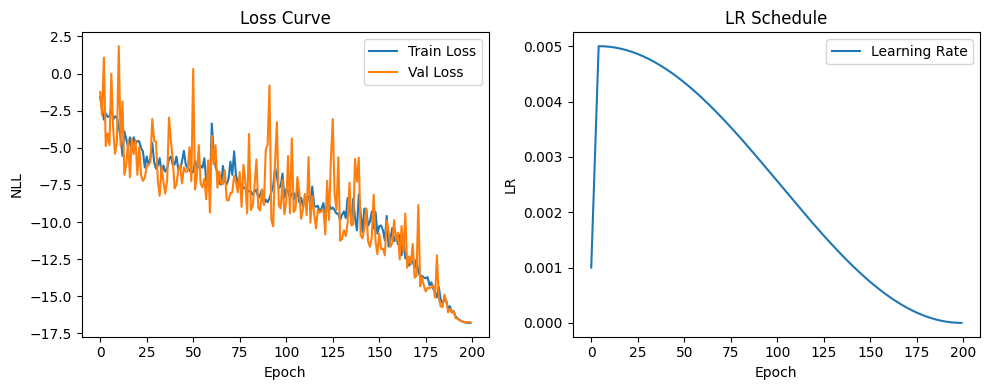

In [23]:
# plot training curves (loss and learning rate)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.train_losses, label='Train Loss')
plt.plot(history.val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('NLL')
plt.title('Loss Curve')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.lrs, label='Learning Rate')
plt.xlabel('Epoch')
plt.ylabel('LR')
plt.title('LR Schedule')
plt.legend()
plt.tight_layout()
plt.show()


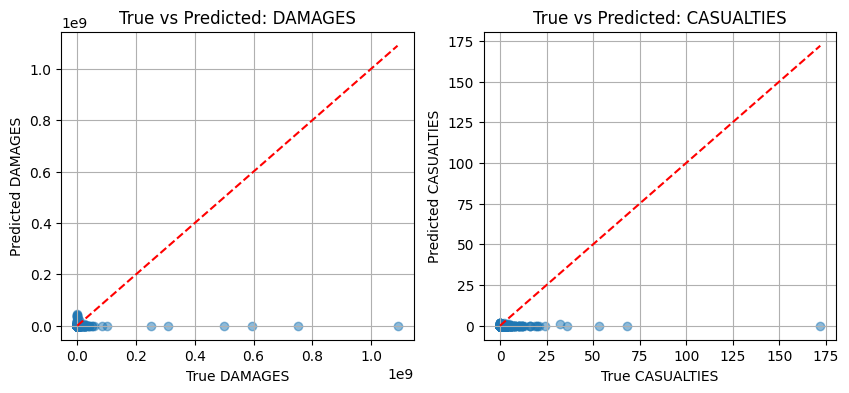

In [24]:
def run_inference_and_plot(flow, test_loader, y_scaler, target_cols, device):
    """
    Run inference for the test set and plot results for damages and casualties
     Parameters
    ----------
    flow        : trained zuko NSF
    test_loader : iterable over the test set
    y_scaler    : y_scaler to plot target feature in its standard input's form
    target_cols : target columns to predict and plot
    device      : device on which we want to work

    Returns
    n plots     : n = len(target_cols)
    """

    flow.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            dist = flow(x_batch)
            y_hat = dist.sample()
            # Ensure y_hat and y_batch are 2D
            if y_hat.ndim == 1:
                y_hat = y_hat.unsqueeze(1)
            if y_batch.ndim == 1:
                y_batch = y_batch.unsqueeze(1)
            y_true.append(y_batch.cpu())
            y_pred.append(y_hat.cpu())
    y_true = torch.cat(y_true, dim=0).numpy()
    y_pred = torch.cat(y_pred, dim=0).numpy()
    if y_true.ndim == 1:
        y_true = y_true.reshape(-1, 1)
    if y_pred.ndim == 1:
        y_pred = y_pred.reshape(-1, 1)
    y_true = y_scaler.inverse_transform(y_true)
    y_pred = y_scaler.inverse_transform(y_pred)
    y_pred = np.expm1(np.clip(y_pred, -20, None))
    y_true = np.expm1(np.clip(y_true, -20, None))
    # Plot for each target
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.scatter(y_true[:, 0], y_pred[:, 0], alpha=0.5)
    plt.xlabel(f"True {target_cols[0]}")
    plt.ylabel(f"Predicted {target_cols[0]}")
    plt.title(f"True vs Predicted: {target_cols[0]}")
    plt.plot([y_true[:, 0].min(), y_true[:, 0].max()], [y_true[:, 0].min(), y_true[:, 0].max()], 'r--')
    plt.grid()
    plt.subplot(1,2,2)
    plt.scatter(y_true[:, 1], y_pred[:, 1], alpha=0.5)
    plt.xlabel(f"True {target_cols[1]}")
    plt.ylabel(f"Predicted {target_cols[1]}")
    plt.title(f"True vs Predicted: {target_cols[1]}")
    plt.plot([y_true[:, 1].min(), y_true[:, 1].max()], [y_true[:, 1].min(), y_true[:, 1].max()], 'r--')
    plt.grid()
    plt.show()



run_inference_and_plot(flow, test_loader, y_scaler, TARGET_COLS, device)

In [25]:
def compute_avg_true_pred_diff(flow, test_loader, y_scaler):
    flow.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            dist = flow(x_batch)
            y_hat = dist.sample().squeeze()
            y_true.append(y_batch.cpu())
            y_pred.append(y_hat.cpu())
    y_true = torch.cat(y_true, dim=0).numpy()
    y_pred = torch.cat(y_pred, dim=0).numpy()
    if y_true.ndim == 1:
        y_true = y_true.reshape(-1, 1)
    if y_pred.ndim == 1:
        y_pred = y_pred.reshape(-1, 1)
    y_true = y_scaler.inverse_transform(y_true)
    y_pred = y_scaler.inverse_transform(y_pred)
    y_pred = np.expm1(np.clip(y_pred, -20, None))
    y_true = np.expm1(np.clip(y_true, -20, None))
    y_pred[:, 1] = np.floor(y_pred[:, 1]).clip(min=0)
    avg_diff_damages = np.mean(np.abs(y_true[:, 0] - y_pred[:, 0]))
    avg_diff_casualties = np.mean(np.abs(y_true[:, 1] - y_pred[:, 1]))
    print(f"Average absolute difference in {TARGET_COLS[0]}: {avg_diff_damages:.2f}")
    print(f"Average absolute difference in {TARGET_COLS[1]}: {avg_diff_casualties:.2f}") 

compute_avg_true_pred_diff(flow, test_loader, y_scaler)

Average absolute difference in DAMAGES: 284971.41
Average absolute difference in CASUALTIES: 0.07


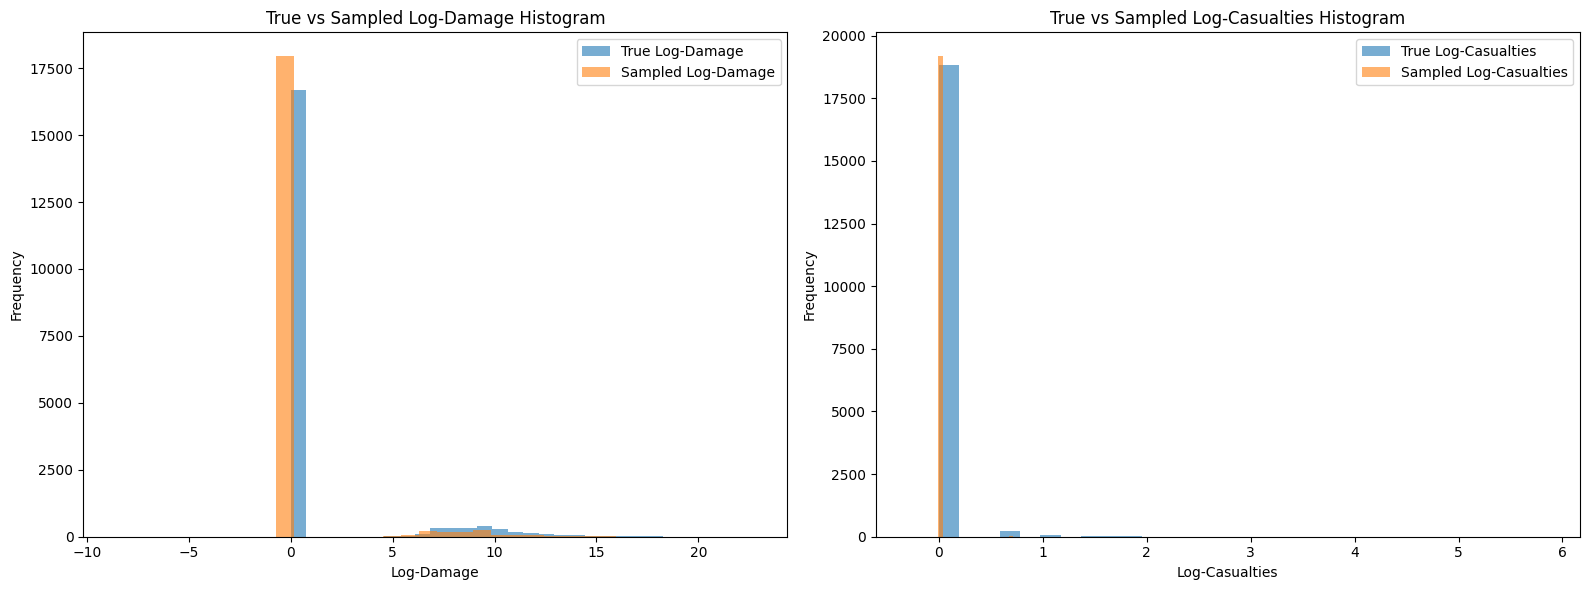

In [26]:
# Plot True log-damage histogram and Sampled log-damage histogram

# Get true log-damage and casualties from Y_test (already standardized)
true_log_damage = y_scaler.inverse_transform(Y_test.cpu().numpy())[:, 0]
true_log_casualties = y_scaler.inverse_transform(Y_test.cpu().numpy())[:, 1]

# Sample log-damage and casualties from flow using X_test as context
flow.eval()
sampled_log = []
with torch.no_grad():
    for i in range(0, X_test.shape[0], 512):
        x_batch = X_test[i:i+512]
        dist = flow(x_batch)
        y_hat = dist.sample()
        if y_hat.ndim == 1:
            y_hat = y_hat.unsqueeze(1)
        sampled_log.append(y_hat.cpu())
sampled_log = torch.cat(sampled_log, dim=0).numpy()
sampled_log_damage = y_scaler.inverse_transform(sampled_log)[:, 0]
sampled_log_casualties = y_scaler.inverse_transform(sampled_log)[:, 1]

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.hist(true_log_damage, bins=30, alpha=0.6, label='True Log-Damage')
plt.hist(sampled_log_damage, bins=30, alpha=0.6, label='Sampled Log-Damage')
plt.xlabel('Log-Damage')
plt.ylabel('Frequency')
plt.title('True vs Sampled Log-Damage Histogram')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(true_log_casualties, bins=30, alpha=0.6, label='True Log-Casualties')
plt.hist(sampled_log_casualties, bins=30, alpha=0.6, label='Sampled Log-Casualties')
plt.xlabel('Log-Casualties')
plt.ylabel('Frequency')
plt.title('True vs Sampled Log-Casualties Histogram')
plt.legend()

plt.tight_layout()
plt.show()